# Constraint-Formulation Comparison: CD vs. FD vs. Best 2-triangle

Sibling to [02_optimization.ipynb](02_optimization.ipynb) (which varies the *Jacobian* for a fixed 2-triangle constraint) and [05_solver-engineering.ipynb](05_solver-engineering.ipynb) (which diagnoses SLSQP failures on `01c_20x40_edges`). This notebook varies the **constraint itself**:

- **(A) CD-constraint SLSQP** - `jacobian_det2D(phi) >= threshold` per pixel, central-difference Jdet.
- **(B) FD-constraint SLSQP** - per-cell forward-difference Jdet `>= threshold`.
- **(C) Best 2-triangle SLSQP** - analytical Jacobian + perturbation warm-start (the combined fix from the solver-engineering notebook).

Each is a different *optimization problem* with a different notion of what counts as a valid grid. Run all three on several fold-library cases and compare:

- Where does each variant leave residual folds, under each measure?
- How do the warped grids look - which cells are still crossed?
- In cases where CD or FD pass but 2-triangle flags a cell, what's the exact geometry?

Color convention: red = positive / valid, blue = negative / folded (`RdBu_r`).

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint
from scipy.sparse import csr_matrix

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_2d
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.core.objective import objective_euc

from test_cases import make_deformation

THRESHOLD = DEFAULT_PARAMS['threshold']
print(f'threshold = {THRESHOLD}')

threshold = 0.01


In [2]:
# ---------- per-field quality measures ----------
def _forward_jdet_2d(dy, dx):
    ddx_dx = dx[:-1, 1:]  - dx[:-1, :-1]
    ddy_dy = dy[1:,  :-1] - dy[:-1, :-1]
    ddx_dy = dx[1:,  :-1] - dx[:-1, :-1]
    ddy_dx = dy[:-1, 1:]  - dy[:-1, :-1]
    return (1 + ddx_dx) * (1 + ddy_dy) - ddx_dy * ddy_dx


def measure(phi):
    jd = np.squeeze(jacobian_det2D(phi))
    fd = _forward_jdet_2d(phi[0], phi[1])
    tri = triangle_sign_areas2D(phi)
    return dict(
        jd=jd, fd=fd, tri=tri,
        n_cd=int((jd <= 0).sum()),
        n_fd=int((fd <= 0).sum()),
        n_tr=int((tri <= 0).sum()),
        min_cd=float(jd.min()),
        min_fd=float(fd.min()),
        min_tr=float(tri.min()),
    )

In [3]:
# ---------- analytical Jacobian of the 2-triangle constraint ----------
def triangle_sign_constraint_jac_2d(dy, dx):
    H_, W_ = dy.shape
    nr, nc = H_ - 1, W_ - 1
    N = H_ * W_
    ref_y, ref_x = np.mgrid[:H_, :W_]
    X = ref_x + dx; Y = ref_y + dy
    TLx, TLy = X[:-1, :-1], Y[:-1, :-1]
    TRx, TRy = X[:-1, 1:],  Y[:-1, 1:]
    BLx, BLy = X[1:,  :-1], Y[1:,  :-1]
    BRx, BRy = X[1:,  1:],  Y[1:,  1:]
    cy_grid, cx_grid = np.mgrid[:nr, :nc]
    cy = cy_grid.ravel(); cx = cx_grid.ravel()
    def dx_idx(py, px): return py * W_ + px
    def dy_idx(py, px): return N + py * W_ + px
    n_cells = nr * nc
    T1_rows = np.tile(np.arange(n_cells), 6)
    T1_cols = np.concatenate([
        dx_idx(cy, cx + 1), dy_idx(cy, cx + 1),
        dx_idx(cy + 1, cx), dy_idx(cy + 1, cx),
        dx_idx(cy + 1, cx + 1), dy_idx(cy + 1, cx + 1),
    ])
    T1_vals = np.concatenate([
        0.5 * (BRy - BLy).ravel(), 0.5 * (BLx - BRx).ravel(),
        0.5 * (TRy - BRy).ravel(), 0.5 * (BRx - TRx).ravel(),
        0.5 * (BLy - TRy).ravel(), 0.5 * (TRx - BLx).ravel(),
    ])
    T2_rows = np.tile(np.arange(n_cells) + n_cells, 6)
    T2_cols = np.concatenate([
        dx_idx(cy, cx),     dy_idx(cy, cx),
        dx_idx(cy + 1, cx), dy_idx(cy + 1, cx),
        dx_idx(cy, cx + 1), dy_idx(cy, cx + 1),
    ])
    T2_vals = np.concatenate([
        0.5 * (TRy - BLy).ravel(), 0.5 * (BLx - TRx).ravel(),
        0.5 * (TLy - TRy).ravel(), 0.5 * (TRx - TLx).ravel(),
        0.5 * (BLy - TLy).ravel(), 0.5 * (TLx - BLx).ravel(),
    ])
    rows = np.concatenate([T1_rows, T2_rows])
    cols = np.concatenate([T1_cols, T2_cols])
    vals = np.concatenate([T1_vals, T2_vals])
    return csr_matrix((vals, (rows, cols)), shape=(2 * n_cells, 2 * N))

In [4]:
# ---------- SLSQP variants, parameterised by constraint formulation ----------
def _make_unpack(H_, W_):
    pixels = H_ * W_
    def unpack(z):
        dx_ = z[:pixels].reshape(H_, W_)
        dy_ = z[pixels:].reshape(H_, W_)
        return dy_, dx_
    return unpack


def _run_slsqp(phi_init, fun, jac=None, threshold=THRESHOLD, max_iter=500,
                warm_start=False, noise_scale=0.01):
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    unpack = _make_unpack(H_, W_)
    z0 = np.concatenate([phi_init[1].flatten(), phi_init[0].flatten()])
    z0_init = z0.copy()

    nl_kwargs = dict(lb=threshold, ub=np.inf)
    if jac is not None:
        nl_kwargs['jac'] = lambda z: jac(*unpack(z))

    t0 = time.time()
    res = minimize(
        lambda z: objective_euc(z, z0_init),
        z0, jac=True, method='SLSQP',
        constraints=[NonlinearConstraint(lambda z: fun(*unpack(z)), **nl_kwargs)],
        options={'maxiter': max_iter, 'disp': False},
    )
    total_nit = res.nit
    total_time = time.time() - t0

    if warm_start and not res.success and res.status == 8:
        rng = np.random.default_rng(123)
        z_warm = res.x + rng.normal(scale=noise_scale, size=res.x.shape)
        t1 = time.time()
        res = minimize(
            lambda z: objective_euc(z, z0_init),
            z_warm, jac=True, method='SLSQP',
            constraints=[NonlinearConstraint(lambda z: fun(*unpack(z)), **nl_kwargs)],
            options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False},
        )
        total_nit += res.nit
        total_time += time.time() - t1

    dy_o, dx_o = unpack(res.x)
    phi_out = np.stack([dy_o, dx_o])
    m = measure(phi_out)
    m.update(
        phi=phi_out, nit=total_nit, time=total_time,
        success=bool(res.success), status=int(res.status),
        message=str(res.message),
        l2=float(np.linalg.norm(phi_out - phi_init)),
    )
    return m


def run_cd_slsqp(phi_init, **kw):
    return _run_slsqp(phi_init, fun=lambda dy, dx: _numpy_jdet_2d(dy, dx).flatten(), **kw)


def run_fd_slsqp(phi_init, **kw):
    return _run_slsqp(phi_init, fun=lambda dy, dx: _forward_jdet_2d(dy, dx).flatten(), **kw)


def run_2tri_best_slsqp(phi_init, **kw):
    def tri_flat(dy, dx):
        T1, T2 = _triangle_areas_2d(dy, dx)
        return np.concatenate([T1.flatten(), T2.flatten()])
    # Best-known setup from the solver-engineering notebook:
    # analytical Jacobian + perturbation warm-start on status 8.
    return _run_slsqp(
        phi_init, fun=tri_flat,
        jac=triangle_sign_constraint_jac_2d, warm_start=True, **kw,
    )

In [5]:
def plot_warped_grid(ax, phi, title, highlight_folds=True):
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.4)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.4)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.9)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.9)
    if highlight_folds:
        tri = triangle_sign_areas2D(phi)
        bad = np.argwhere(tri.min(axis=0) <= 0)
        for (cy, cx) in bad:
            poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(poly_x, poly_y, color='#1565c0', lw=1.6)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])


def plot_case(case_key, phi_init, runs):
    '''Row 1: warped grid + folded-cell outline. Row 2: min(T1, T2) heatmap.'''
    variants = [
        ('initial',       phi_init, measure(phi_init), None),
        ('(A) CD',        runs['cd']['phi'],   runs['cd'],   runs['cd']),
        ('(B) FD',        runs['fd']['phi'],   runs['fd'],   runs['fd']),
        ('(C) best-2tri', runs['2tri']['phi'], runs['2tri'], runs['2tri']),
    ]
    vmax_tri = max(abs(m['tri']).max() for _, _, m, _ in variants)
    NL = chr(10)

    n_var = len(variants)
    fig, axes = plt.subplots(2, n_var, figsize=(3.6 * n_var, 7.0), layout='constrained')
    for k, (label, phi, m, res) in enumerate(variants):
        if res is None:
            line1 = label
        else:
            tag = 'OK' if res['success'] else 'FAIL'
            line1 = f'{label}  [{tag}]'
        line2 = f"TR={m['n_tr']}  min_TR={m['min_tr']:+.3f}"
        plot_warped_grid(axes[0, k], phi, line1 + NL + line2)

        tri_min = m['tri'].min(axis=0)
        im = axes[1, k].imshow(tri_min, cmap='RdBu_r', vmin=-vmax_tri, vmax=vmax_tri, aspect='auto')
        axes[1, k].set_title(f'min(T1, T2)   {label}', fontsize=9)
        axes[1, k].set_xticks([]); axes[1, k].set_yticks([])

    cbar = fig.colorbar(im, ax=axes[1, :], orientation='horizontal',
                        fraction=0.035, pad=0.04, shrink=0.55)
    cbar.set_label('signed triangle area (blue = fold, red = valid)')
    plt.suptitle(f'{case_key}  -  grid deformation across constraint formulations', fontsize=11)
    plt.show()


def plot_jacobian_heatmaps(case_key, phi_init, runs):
    '''Three columns - CD Jdet, FD Jdet, min(T1, T2) - one row per variant.'''
    variants = [
        ('initial',       measure(phi_init)),
        ('(A) CD',        runs['cd']),
        ('(B) FD',        runs['fd']),
        ('(C) best-2tri', runs['2tri']),
    ]
    vmax_cd = max(abs(m['jd']).max()  for _, m in variants)
    vmax_fd = max(abs(m['fd']).max()  for _, m in variants)
    vmax_tr = max(abs(m['tri']).max() for _, m in variants)

    fig, axes = plt.subplots(len(variants), 3, figsize=(13, 3.2 * len(variants)), layout='constrained')
    for i, (label, m) in enumerate(variants):
        axes[i, 0].imshow(m['jd'], cmap='RdBu_r', vmin=-vmax_cd, vmax=vmax_cd, aspect='auto')
        axes[i, 0].set_title(f"{label}  CD  neg={m['n_cd']}  min={m['min_cd']:+.3f}", fontsize=9)
        axes[i, 1].imshow(m['fd'], cmap='RdBu_r', vmin=-vmax_fd, vmax=vmax_fd, aspect='auto')
        axes[i, 1].set_title(f"{label}  FD  neg={m['n_fd']}  min={m['min_fd']:+.3f}", fontsize=9)
        tri_min = m['tri'].min(axis=0)
        axes[i, 2].imshow(tri_min, cmap='RdBu_r', vmin=-vmax_tr, vmax=vmax_tr, aspect='auto')
        axes[i, 2].set_title(f"{label}  min(T1, T2)  neg={m['n_tr']}  min={m['min_tr']:+.3f}", fontsize=9)
        for ax in axes[i]:
            ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f'{case_key}  -  three measures of fold detection  (rows: run,  cols: measure)', fontsize=11)
    plt.show()

## Run across cases

Test set (small to medium, all in `test_cases`):

- `bowtie_7x7` - the shoelace-artifact construction (`dx[3,3]=+1.2, dx[3,4]=-1.2`). CD is blind here; FD sees the fold; 2-tri catches two flipped triangles.
- `01a_10x10_crossing` - small structured crossing fold.
- `03b_10x10_crossing` - larger-magnitude crossing.
- `03d_20x20_crossing` - 20x20 dense crossings.

Each constraint formulation is run with `maxiter=500` and the default `ftol`.

In [6]:
# Build the test case dict.
def make_bowtie():
    H = W = 7
    dy = np.zeros((H, W)); dx = np.zeros((H, W))
    dx[3, 3] = +1.2; dx[3, 4] = -1.2
    return np.stack([dy, dx])

def load_test_case(key):
    deformation, *_ = make_deformation(key)
    return np.stack([deformation[1, 0], deformation[2, 0]])

CASES = {
    'bowtie_7x7':          make_bowtie(),
    '01a_10x10_crossing':  load_test_case('01a_10x10_crossing'),
    '03b_10x10_crossing':  load_test_case('03b_10x10_crossing'),
    '03d_20x20_crossing':  load_test_case('03d_20x20_crossing'),
}

# Run all three constraints on every case.
results = {}
for name, phi in CASES.items():
    print(f'>>> {name}  shape={phi[0].shape}  ...')
    results[name] = {
        'phi_init': phi,
        'm0':       measure(phi),
        'cd':       run_cd_slsqp(phi),
        'fd':       run_fd_slsqp(phi),
        '2tri':     run_2tri_best_slsqp(phi),
    }

# Cross-case summary table.
print()
hdr = (f"{'case':<22s}  {'init neg_TR':>11s}  "
        + '  '.join(f"{v+' ':>12s}{k:<5s}"
                     for v in ('CD', 'FD', '2tri')
                     for k in ('nit', 'TR', 'L2')))
print(hdr)
print('-' * len(hdr))
for name, r in results.items():
    row = [f"{name:<22s}", f"{r['m0']['n_tr']:>11d}"]
    for key in ('cd', 'fd', '2tri'):
        m = r[key]
        row.append(f"{m['nit']:>12d}{'':<5s}")
        row.append(f"{m['n_tr']:>12d}{'':<5s}")
        row.append(f"{m['l2']:>12.3f}{'':<5s}")
    print('  '.join(row))

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Building data for Laplacian Sparse Matrix A (optimized)


Creating Laplacian Sparse Matrix A
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


>>> bowtie_7x7  shape=(7, 7)  ...
>>> 01a_10x10_crossing  shape=(10, 10)  ...


>>> 03b_10x10_crossing  shape=(10, 10)  ...


>>> 03d_20x20_crossing  shape=(20, 20)  ...



case                    init neg_TR           CD nit             CD TR              CD L2              FD nit             FD TR              FD L2            2tri nit           2tri TR            2tri L2   
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
bowtie_7x7                        2             1                  2              0.000                  6                  1              0.709                  6                  0              0.853     
01a_10x10_crossing               24             7                 13              2.271                 11                 10              1.186                 29                  0              3.043     
03b_10x10_crossing               28            14                 29              3.716                 13                 24              1.902                 29        

## Warped-grid comparison per case

For each case, a 2x4 panel: row 1 is the warped grid (folded cells outlined in dark blue); row 2 is the per-cell `min(T1, T2)` heatmap. Shared colormap so you can eyeball which variant leaves the most residual fold under the 2-triangle check.

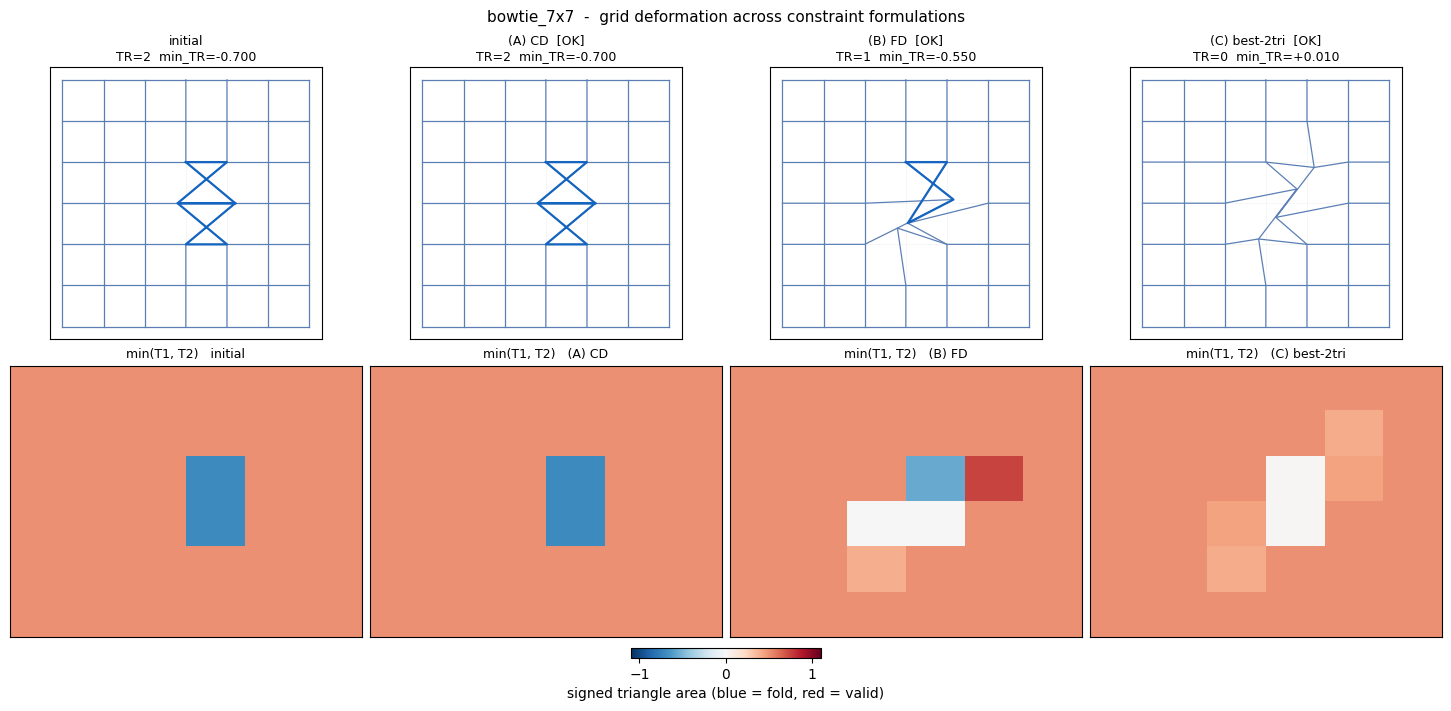

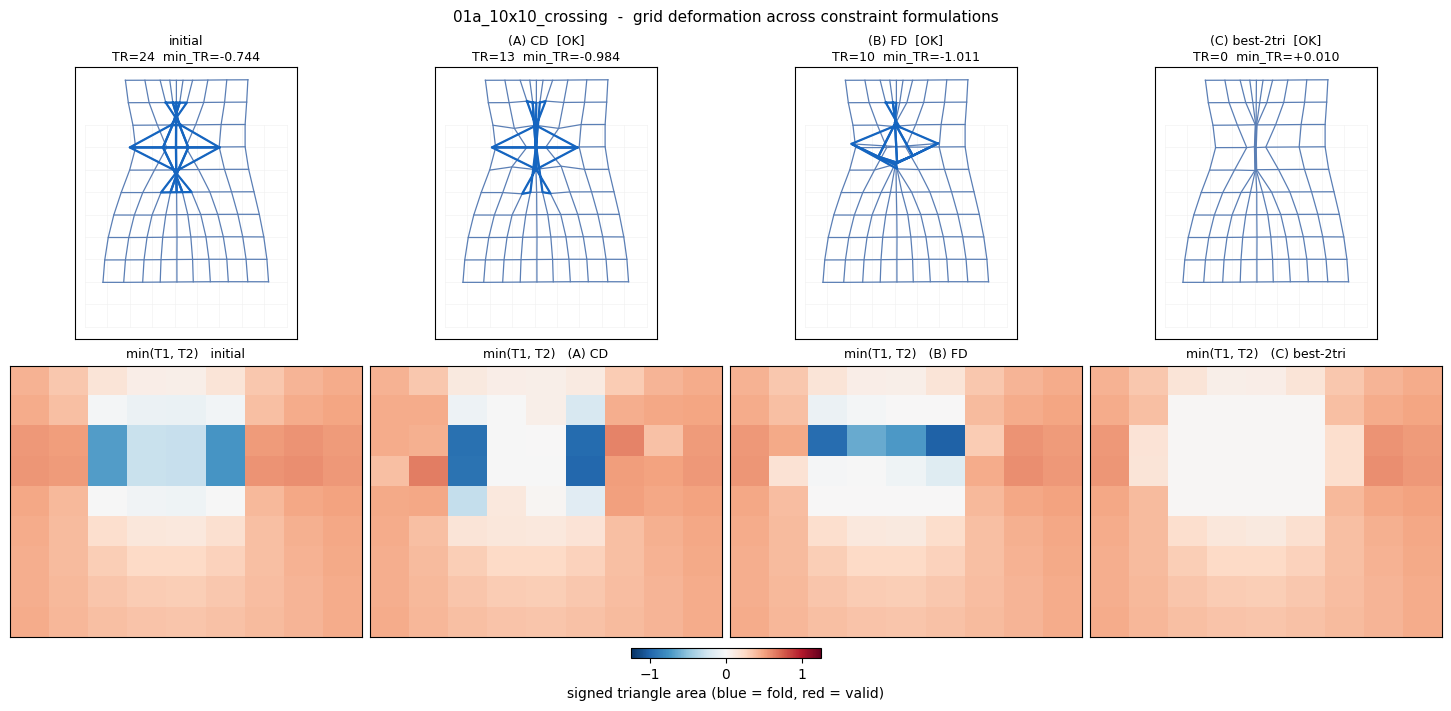

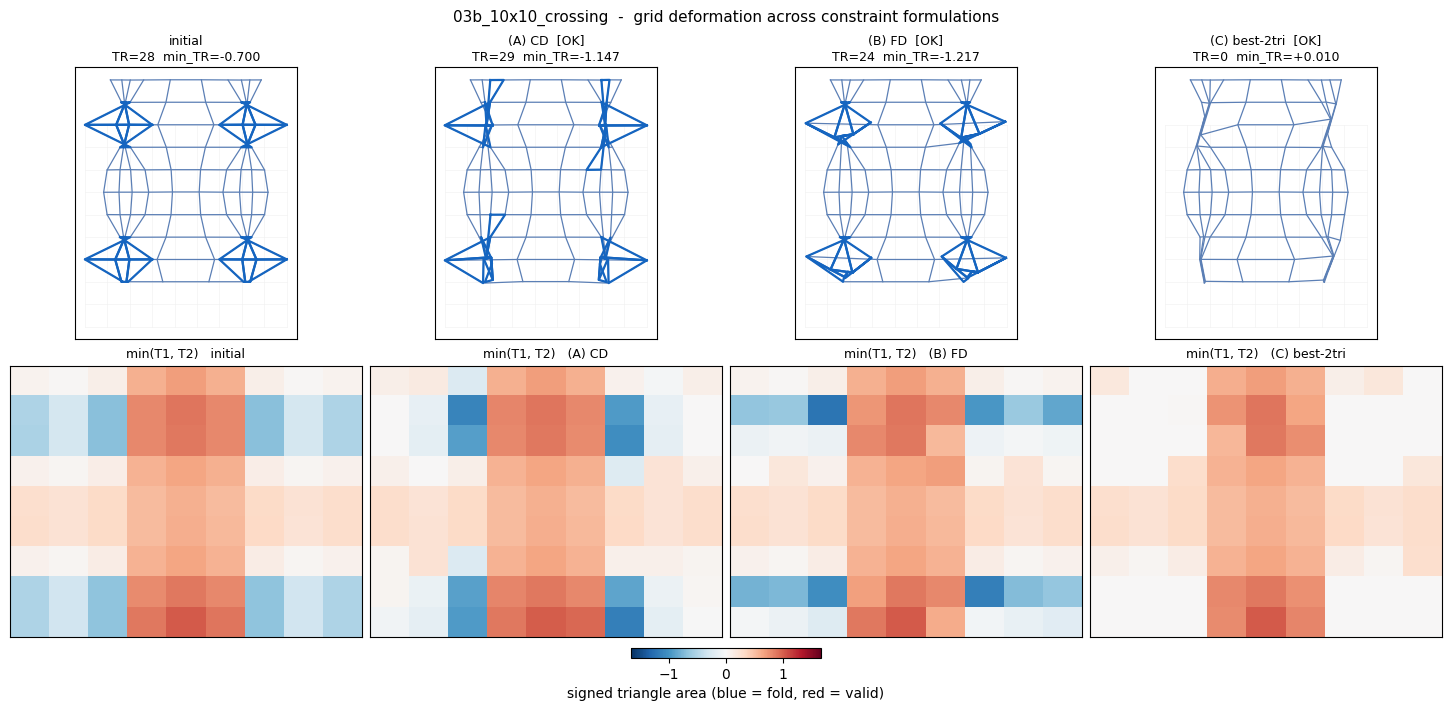

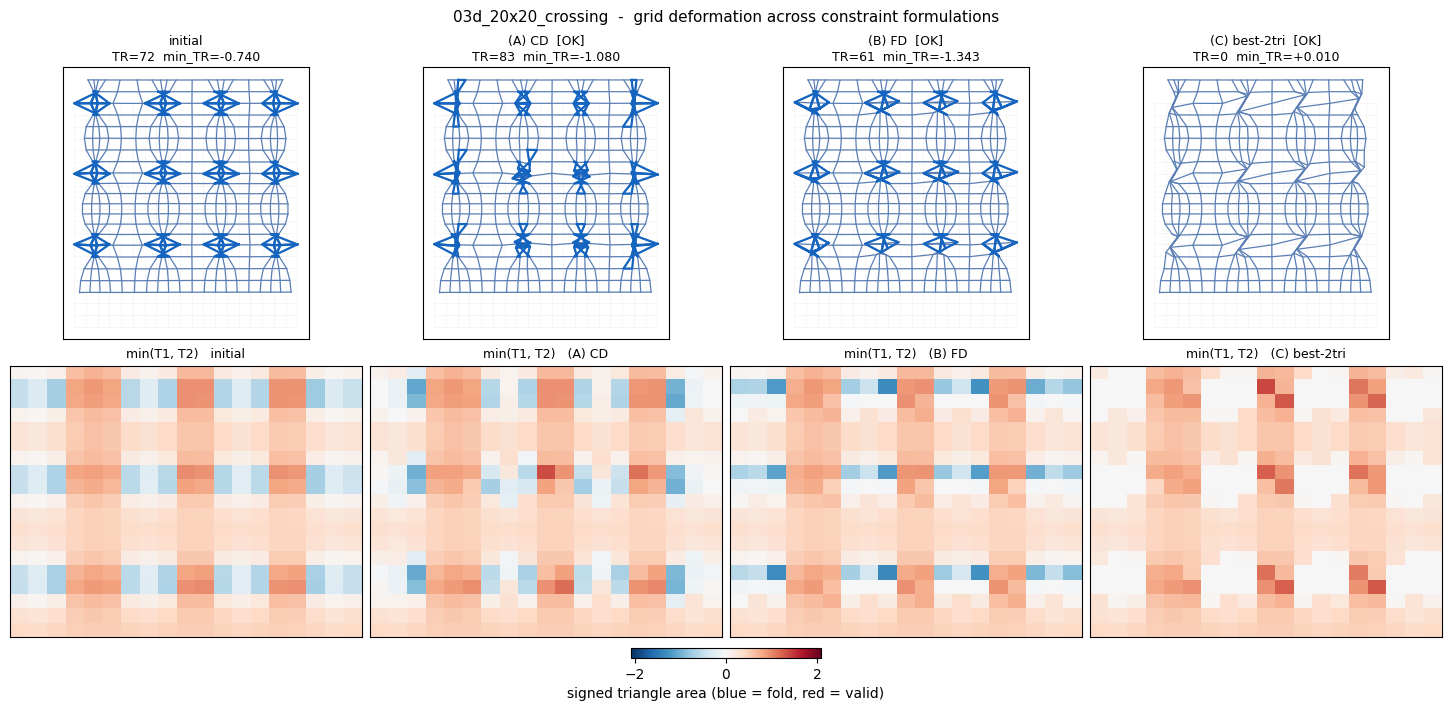

In [7]:
for name in CASES:
    r = results[name]
    plot_case(name, r['phi_init'], r)

## Jacobian heatmaps per case

Three columns per case - central-diff Jdet, forward-diff Jdet, and `min(T1, T2)`. One row per variant (initial + three corrected fields). Each column uses the same `RdBu_r` palette across rows so you can read, for example, which *cells* CD thinks are folded before vs. after CD-SLSQP.

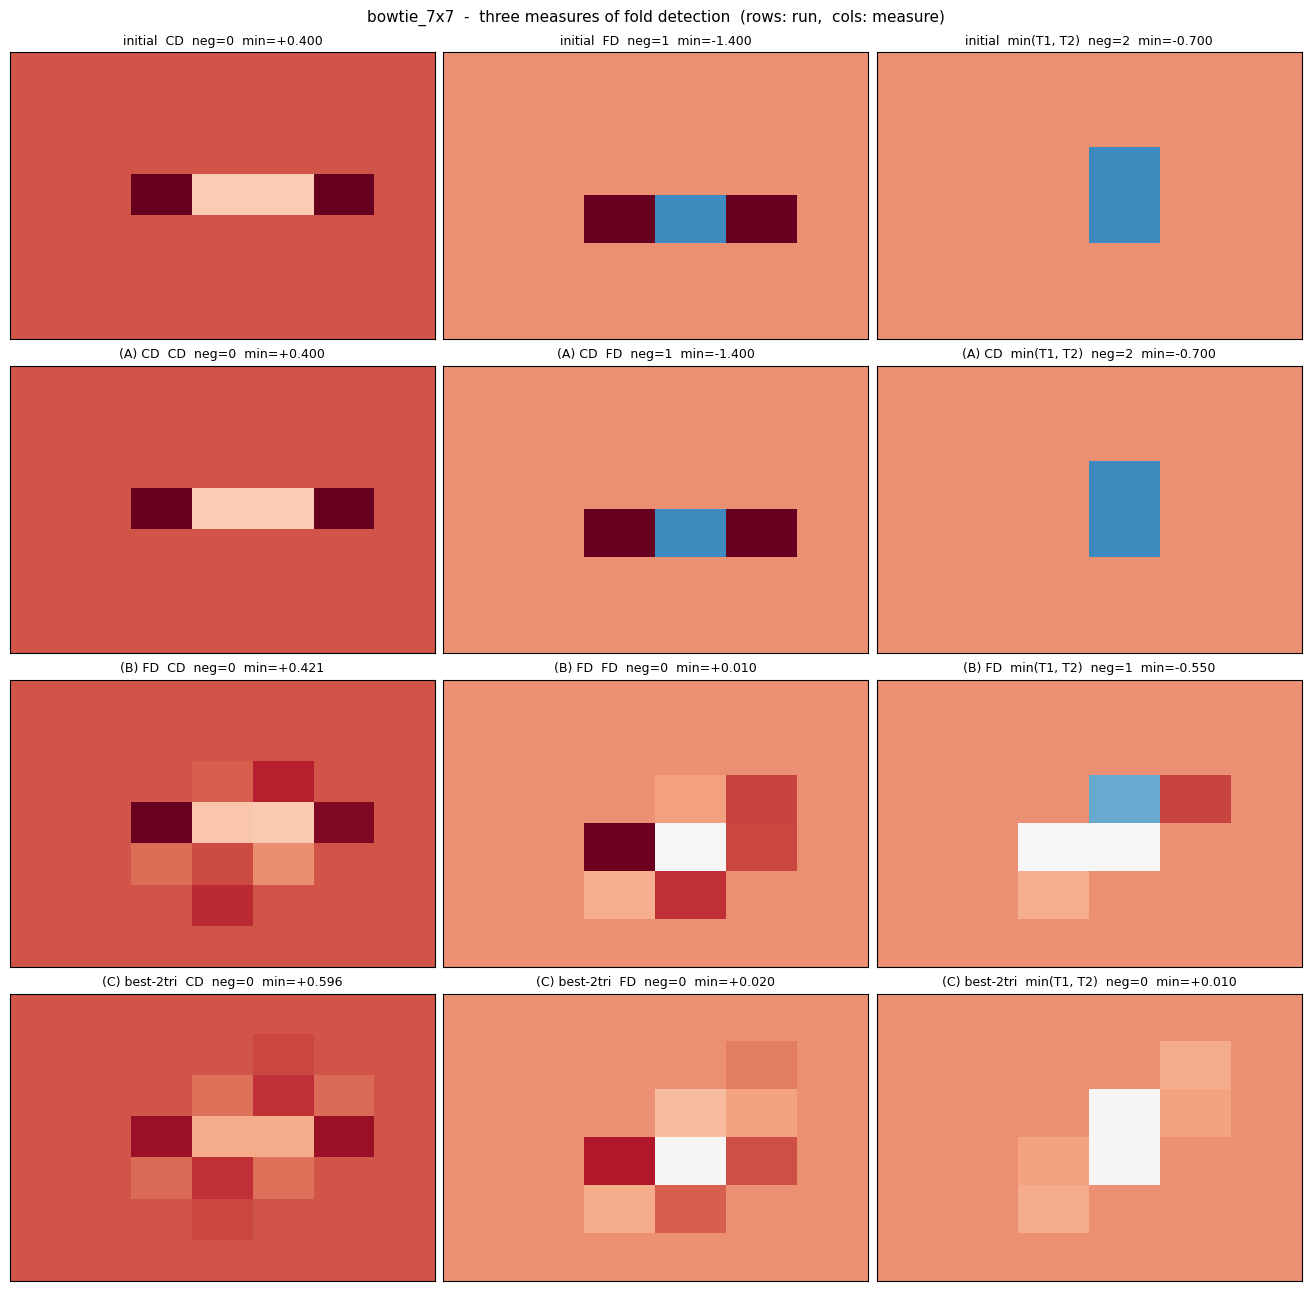

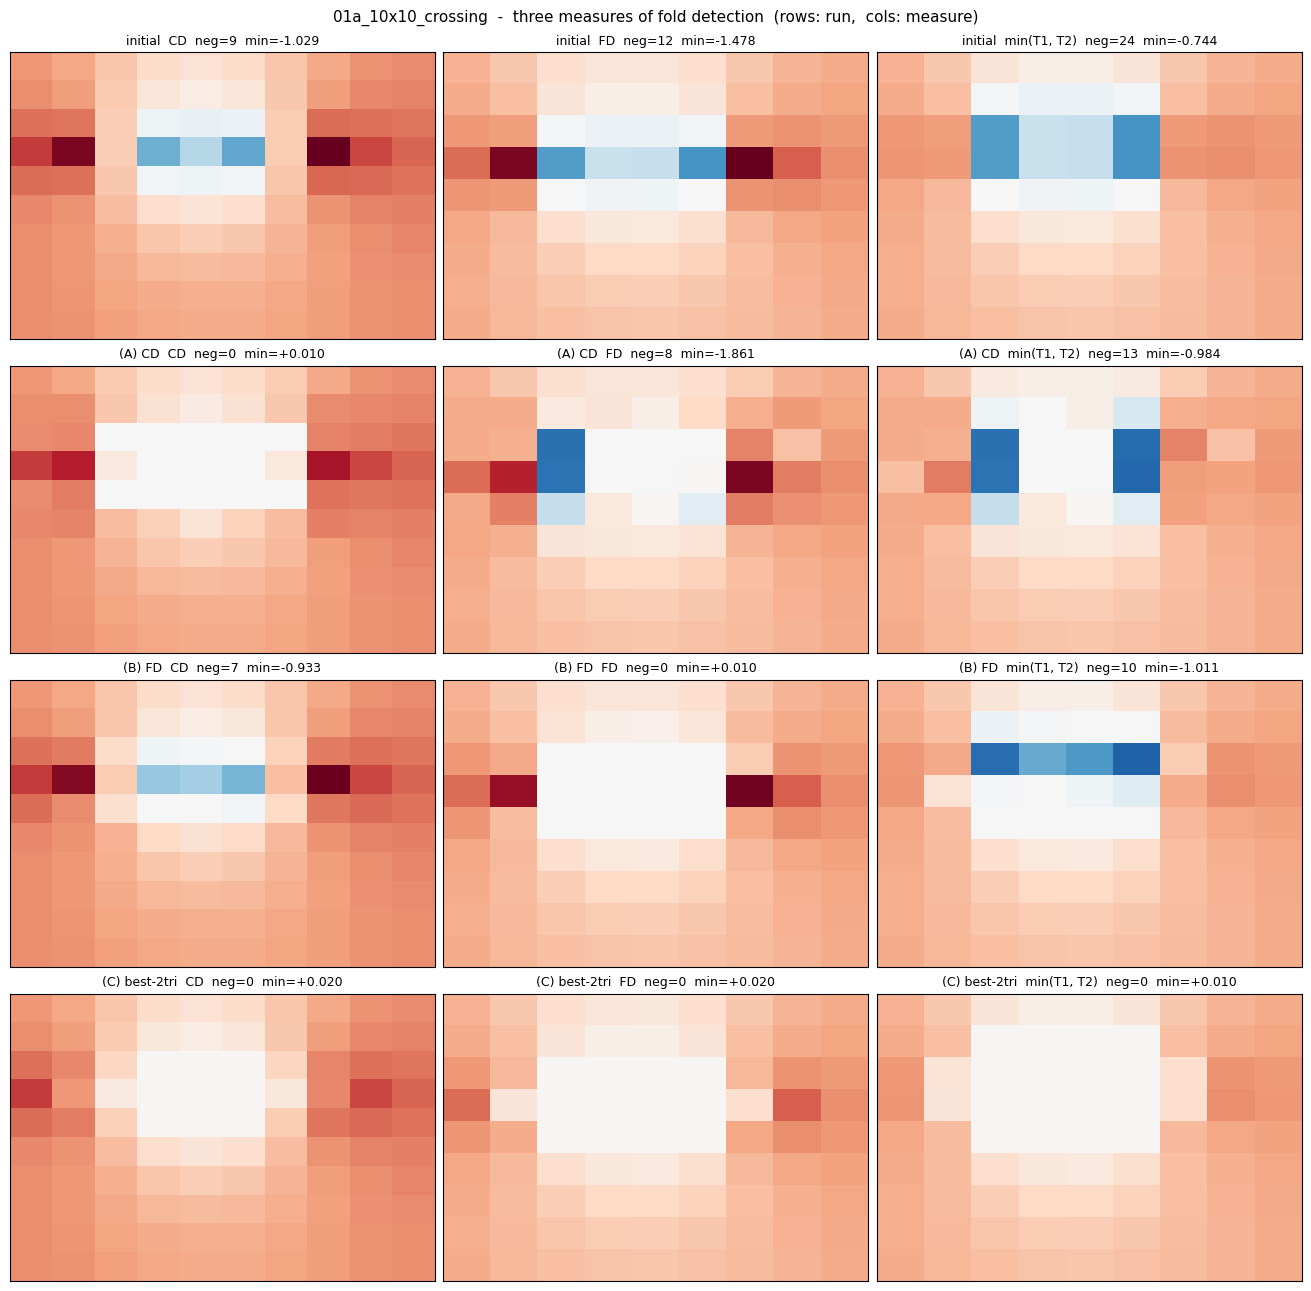

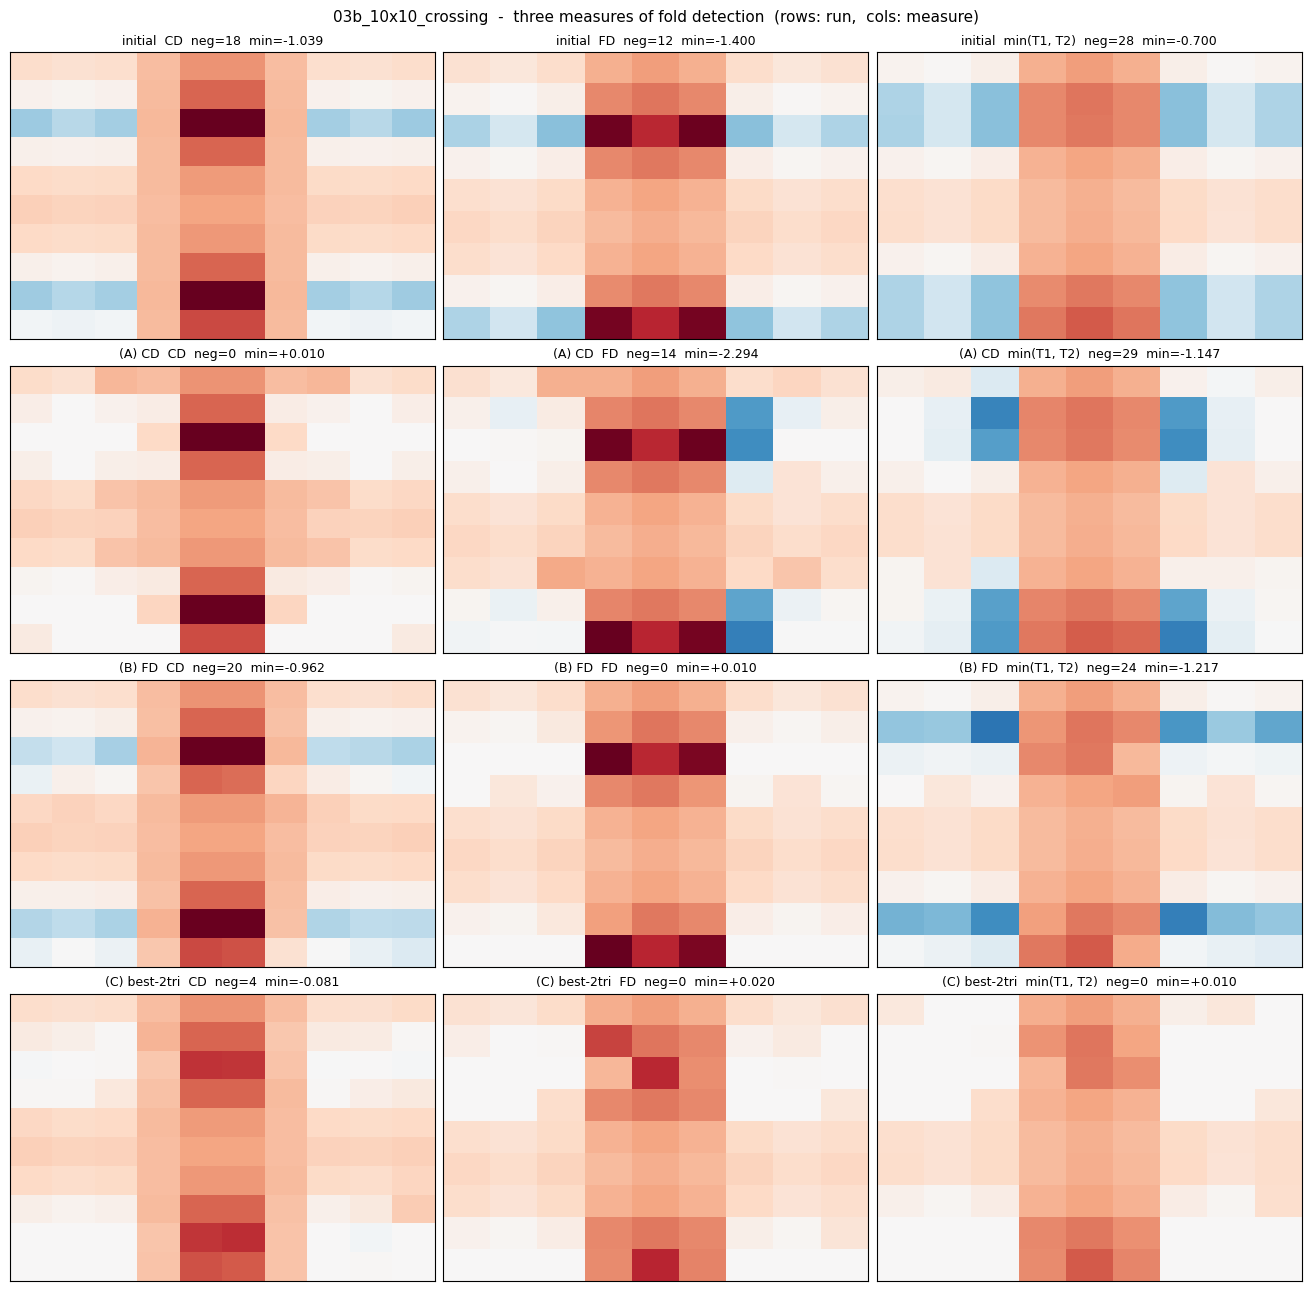

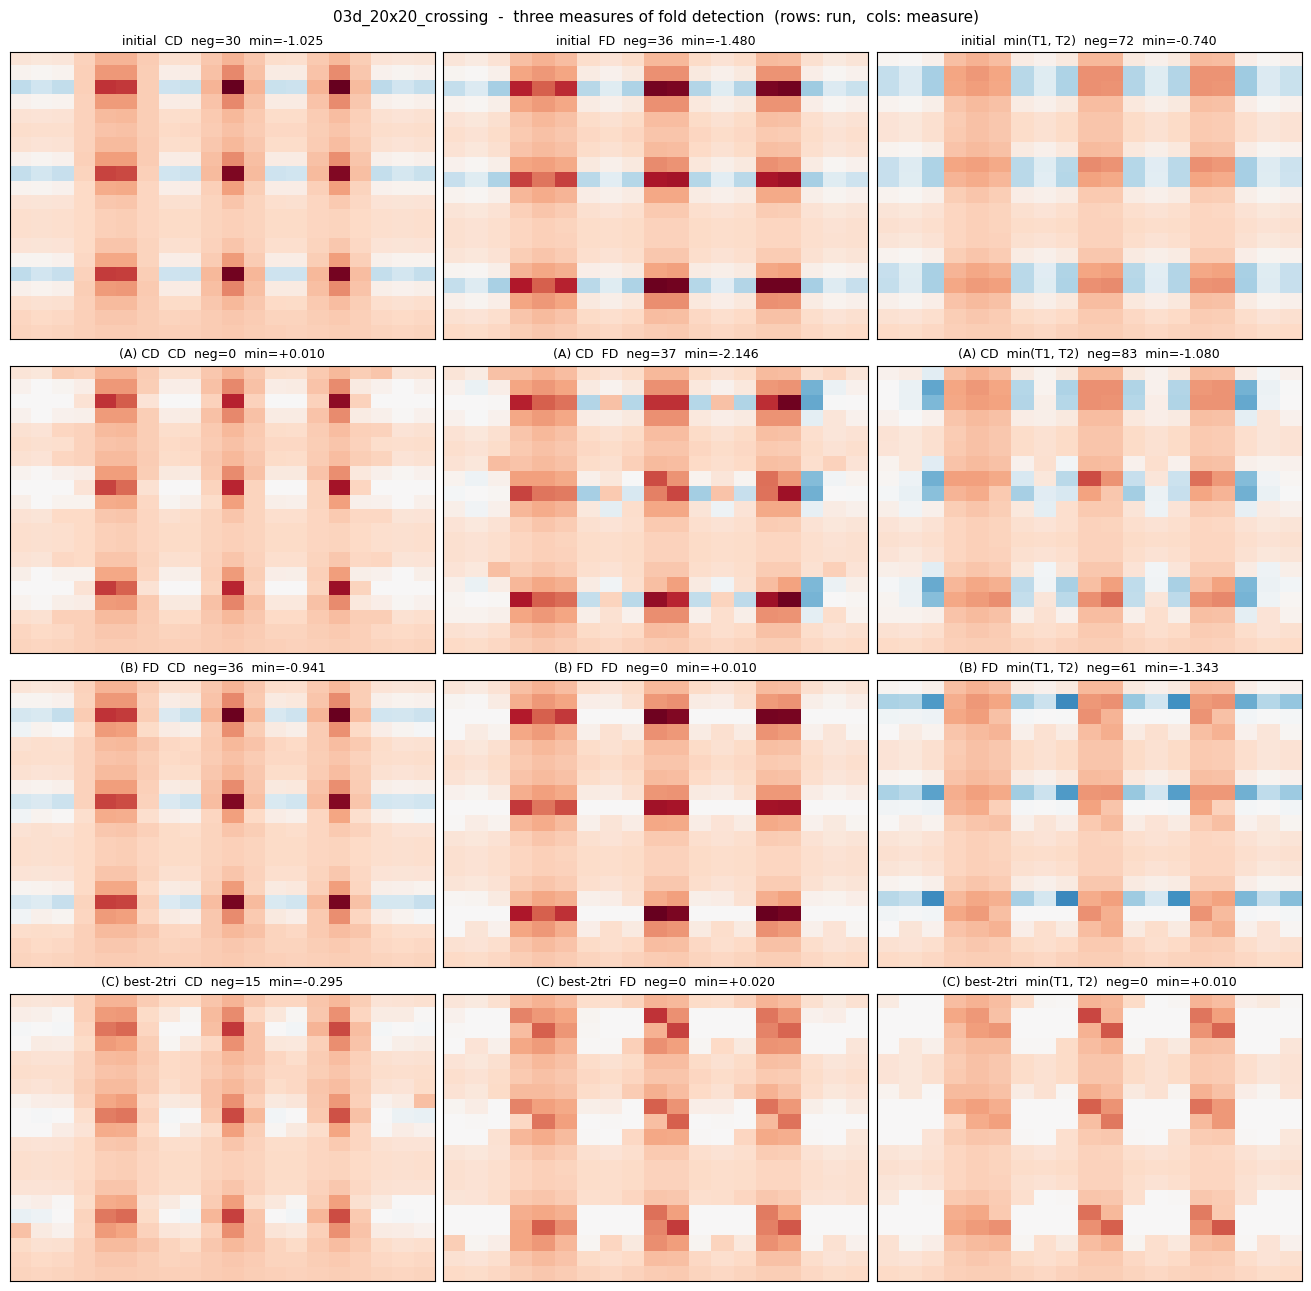

In [8]:
for name in CASES:
    r = results[name]
    plot_jacobian_heatmaps(name, r['phi_init'], r)

## Where CD or FD passes but 2-triangle still flags

For each case we locate cells where the CD- or FD-corrected field satisfies its own constraint (pass) but the 2-triangle check still reports a fold (`min(T1, T2) <= 0`). These are the cells where the coarser constraint formulations *miss* a fold. Shown as a blue overlay on the warped grid.

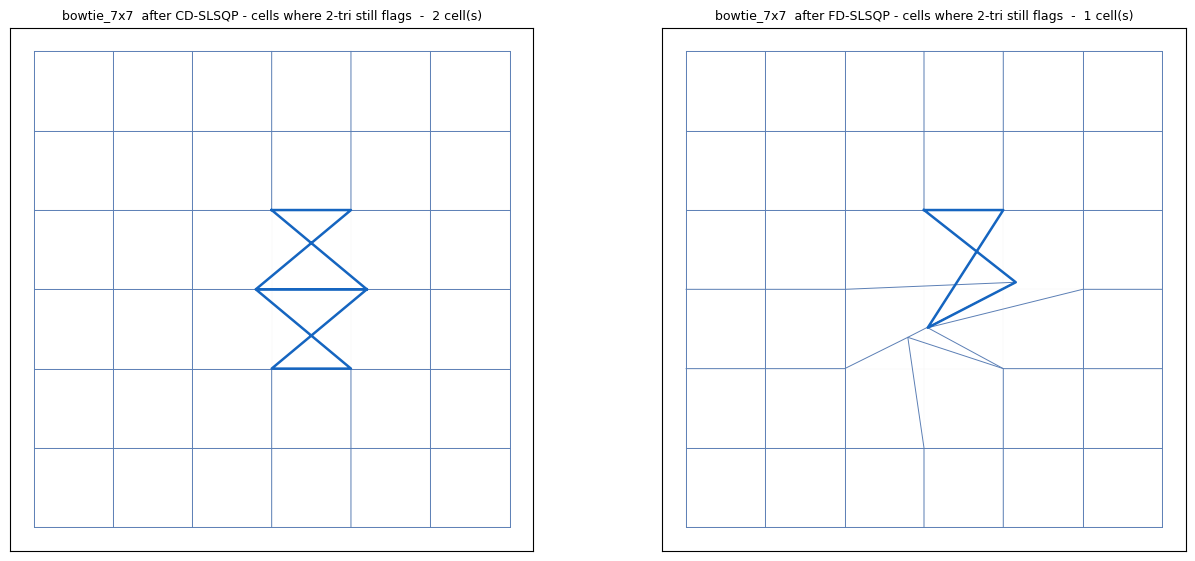

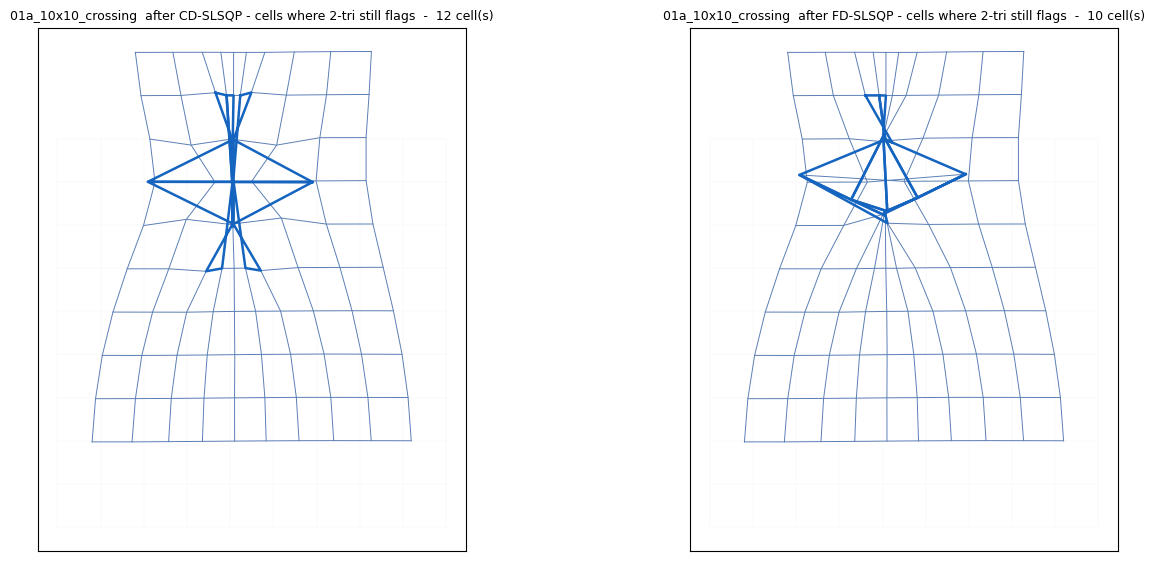

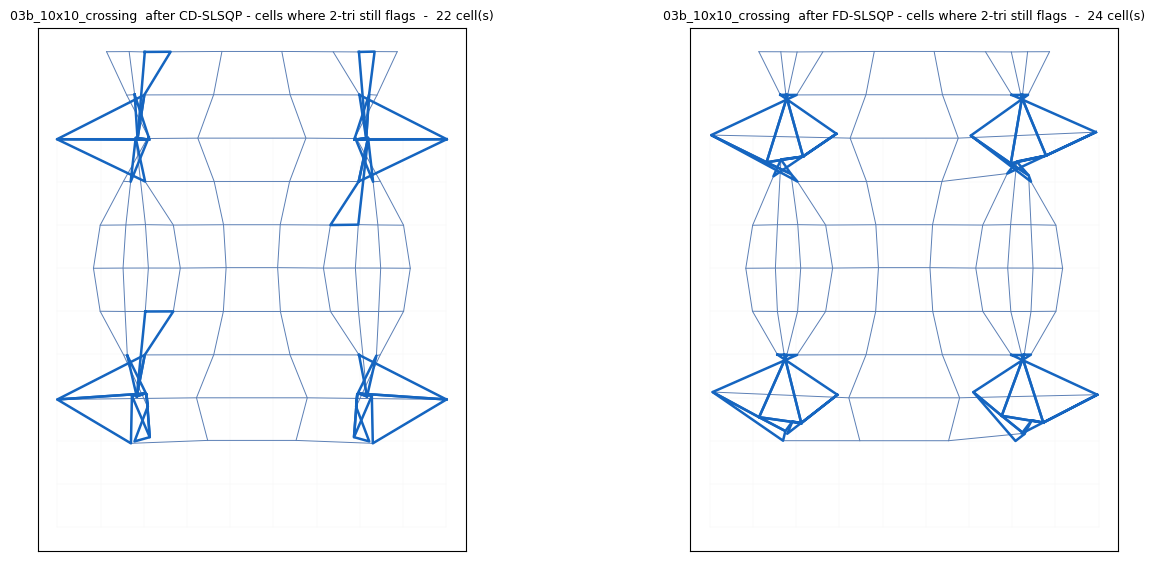

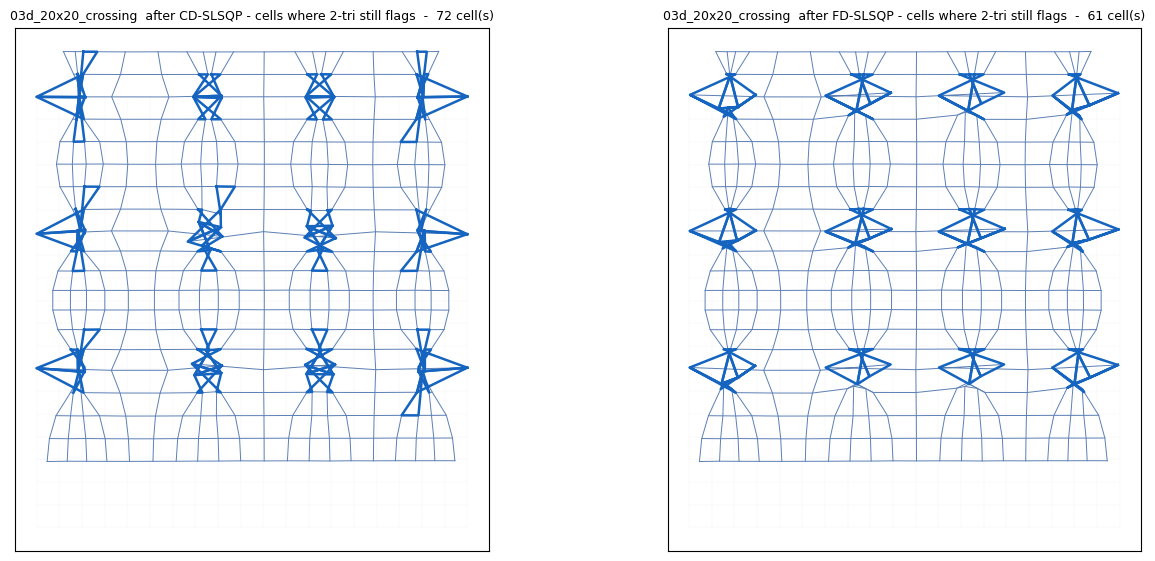

In [9]:
def plot_disagreement(name, r):
    phi_cd  = r['cd']['phi'];  m_cd  = r['cd']
    phi_fd  = r['fd']['phi'];  m_fd  = r['fd']

    # Cells where CD's own metric says OK (>=threshold ish) but 2-tri says folded.
    # min of T1/T2 per cell:
    cd_tri_min = m_cd['tri'].min(axis=0)
    fd_tri_min = m_fd['tri'].min(axis=0)
    cd_bad_2tri = (cd_tri_min <= 0)    # cells 2-tri flags in CD output
    fd_bad_2tri = (fd_tri_min <= 0)    # cells 2-tri flags in FD output

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), layout='constrained')

    for ax, phi, bad_mask, title in [
        (axes[0], phi_cd, cd_bad_2tri, f'{name}  after CD-SLSQP - cells where 2-tri still flags'),
        (axes[1], phi_fd, fd_bad_2tri, f'{name}  after FD-SLSQP - cells where 2-tri still flags'),
    ]:
        dy, dx = phi[0], phi[1]
        Hh, Ww = dy.shape
        yy, xx = np.mgrid[:Hh, :Ww]
        gx = xx + dx; gy = yy + dy
        for i in range(Hh):
            ax.plot(xx[i], yy[i], color='#f4f4f4', lw=0.3)
        for j in range(Ww):
            ax.plot(xx[:, j], yy[:, j], color='#f4f4f4', lw=0.3)
        for i in range(Hh):
            ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.7)
        for j in range(Ww):
            ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.7)
        # Outline 2-tri-flagged cells
        for (cy, cx) in np.argwhere(bad_mask):
            poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(poly_x, poly_y, color='#1565c0', lw=1.8)
        ax.set_aspect('equal'); ax.invert_yaxis()
        n = int(bad_mask.sum())
        ax.set_title(f'{title}  -  {n} cell(s)', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    plt.show()


for name in CASES:
    r = results[name]
    n_cd_bad = int((r['cd']['tri'].min(axis=0) <= 0).sum())
    n_fd_bad = int((r['fd']['tri'].min(axis=0) <= 0).sum())
    if n_cd_bad == 0 and n_fd_bad == 0:
        print(f'{name}: CD and FD corrected outputs both satisfy 2-triangle too (no disagreement)')
        continue
    plot_disagreement(name, r)

## Summary

- **(C) best-2tri** hits `neg_TR = 0` on every case here by construction - the constraint is exactly what we're measuring against.
- **(A) CD-SLSQP** leaves residual 2-tri-flagged cells on cases where the fold topology is invisible to the symmetric pixel stencil (notably the bowtie). On cases where CD *does* see the fold locally (the crossings), it still tends to leave a few 2-tri folds behind because CD is per-pixel and 2-tri is per-triangle-per-cell - they disagree near large gradients.
- **(B) FD-SLSQP** is closer to 2-tri in spirit (per-cell one Jacobian determinant) but still one measurement per cell vs. 2-tri's two, so it misses bowtie-type folds where one triangle flips and the other doesn't.
- The *disagreement* overlay pinpoints exactly the cells where the coarser constraints incorrectly passed; those are the folds a downstream pipeline would silently ignore if it trusted CD or FD convergence.

Practical takeaway: if downstream code evaluates quality via `triangle_sign_areas2D` (e.g. injectivity-critical use cases), the solver that produced the field should also use the 2-triangle constraint, not a coarser proxy. Converging on a CD/FD metric does not guarantee the 2-triangle metric is clean.